## ИСХОДЫ ПРИМЕНЕНИЯ И ПРОВЕРКИ МОДЕЛИ
### Для бинарной классификации (0 или 1)
##### истинно положительные (TP) - Модель «сказала» 1 и в выборке 1
##### истинно отрицательные (TN) - Модель «сказала» 0 и в выборке 0
##### ложно положительные (FP)   - Модель «сказала» 1 и в выборке 0
##### ложно отрицательные (FN)   - Модель «сказала» 0 и в выборке 1

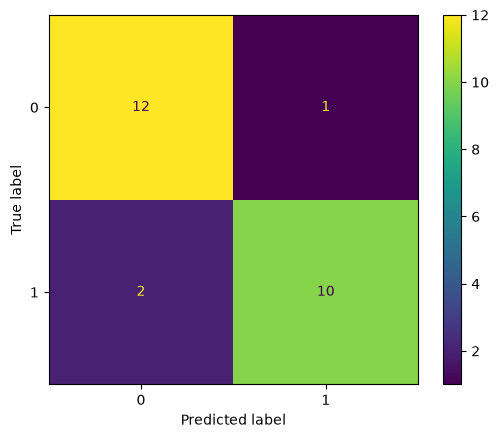

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
X, y = make_classification(random_state=0)
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    random_state=0)
clf = DecisionTreeClassifier(random_state=0)
clf.fit(X_train, y_train)
predictions = clf.predict(X_test)
cm = confusion_matrix(y_test, predictions, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=clf.classes_)
disp.plot()
plt.show()

In [2]:
from sklearn.metrics import confusion_matrix
y_true = [2, 0, 2, 2, 0, 1]
y_pred = [0, 0, 2, 2, 0, 2]
confusion_matrix(y_true, y_pred)

array([[2, 0, 0],
       [0, 0, 1],
       [1, 0, 2]])

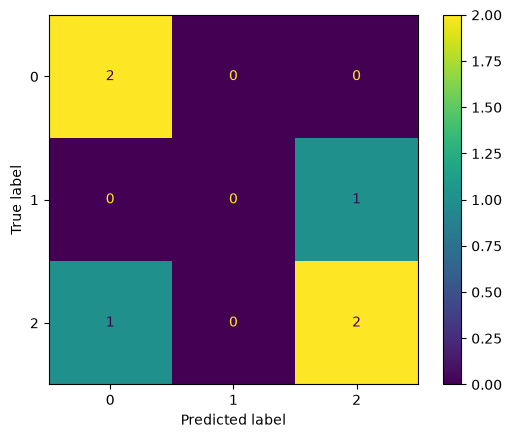

In [3]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred)).plot()

## 𝐴𝑐𝑐𝑢𝑟𝑎𝑐𝑦
Одной из наиболее простых, а поэтому и распространенной метрикой является точность(𝐴𝑐𝑐𝑢𝑟𝑎𝑐𝑦).

Она показывает количество правильно проставленных меток класса (истинно положительных и истинно отрицательных) от общего количества данных

In [4]:
import numpy as np
import sklearn.metrics
from sklearn.metrics import accuracy_score
y_pred = [0, 2, 1, 3]
y_true = [0, 1, 2, 3]
accuracy_score(y_true, y_pred)

0.5

## 𝑃𝑟𝑒𝑐𝑖𝑠𝑖𝑜𝑛
Эта точность показывает количество истинно положительных исходов из всего набора положительных меток
Важность этой метрики определяется тем, насколько высока для рассматриваемой задачи «цена» ложно положительного результата. 

In [5]:
from sklearn import metrics
y_pred = [0, 1, 0, 0]
y_true = [0, 1, 0, 1]
metrics.precision_score(y_true, y_pred)

1.0

## 𝑅𝑒𝑐𝑎𝑙𝑙 (true positive rate)
В русском языке для этого термина используется слово «полнота» или «чувствительность». Эта метрика определяет количество истинно положительных среди всех меток класса, которые были определены как «положительный»
Необходимо уделить особое внимание этой оценке, когда в поставленной задаче ошибка нераспознания положительного класса высока, например, при выставлении диагноза какой-либо смертельной болезни.

In [6]:
metrics.recall_score(y_true, y_pred)

0.5

## 𝐹1−𝑆𝑐𝑜𝑟𝑒
В том случае, если Precision и Recall являются одинаково значимыми, можно использовать их среднее гармоническое для получения оценки результатов


In [10]:
metrics.f1_score(y_true, y_pred)

0.6666666666666666

## Classification report

In [11]:
from sklearn.metrics import classification_report
y_true = [0, 1, 2, 2, 0]
y_pred = [0, 0, 2, 1, 0]
target_names = ['class 0', 'class 1', 'class 2']
print(classification_report(y_true, y_pred, target_names=target_names))

              precision    recall  f1-score   support

     class 0       0.67      1.00      0.80         2
     class 1       0.00      0.00      0.00         1
     class 2       1.00      0.50      0.67         2

    accuracy                           0.60         5
   macro avg       0.56      0.50      0.49         5
weighted avg       0.67      0.60      0.59         5



## ROC

In [12]:
import numpy as np
from sklearn.metrics import roc_curve
y = np.array([1, 1, 2, 2])
scores = np.array([0.1, 0.4, 0.35, 0.8])
fpr, tpr, thresholds = roc_curve(y, scores, pos_label=2)
fpr
tpr
thresholds

array([ inf, 0.8 , 0.4 , 0.35, 0.1 ])

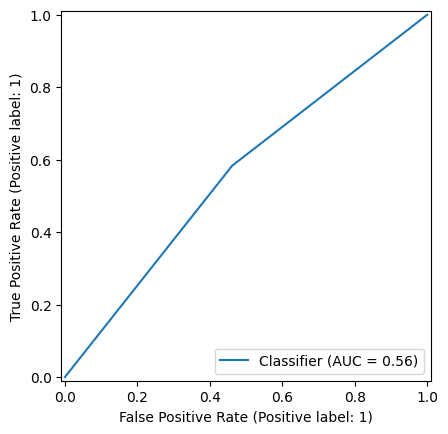

In [13]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X, y = make_classification(random_state=0)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=0)
clf = DecisionTreeClassifier(random_state=0).fit(X_train, y_train)


# predict_proba возвращает две вероятности в виде массива. 
#Для ROC кривой нам нужна первая вероятность
y_pred = clf.predict_proba(X_test).ravel()[:len(y_test)] 


RocCurveDisplay.from_predictions(
   y_test, y_pred)
plt.show()